[[ 0.00000000e+00  9.70976037e-02  1.91030586e-01 ... -1.94347485e+01
  -8.13889042e+00  0.00000000e+00]
 [ 0.00000000e+00  1.83059269e-01  3.18985431e-01 ... -7.95709567e+00
  -9.89946132e+00  0.00000000e+00]
 [ 0.00000000e+00  2.19939378e-01  2.21434788e-01 ... -8.81938853e-02
  -1.38578551e-01  0.00000000e+00]
 [ 0.00000000e+00  3.52645324e-06  2.45113246e-05 ... -2.22904402e-02
  -2.08401924e-02  0.00000000e+00]]
[[  0.           0.09709763   0.19103089 ...   9.37666468  29.25872325
    0.        ]
 [  0.           0.18305931   0.318986   ...  -7.84351879 -10.78054276
    0.        ]
 [  0.           0.21993943   0.22143543 ...  -0.09097453  -0.14200324
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]


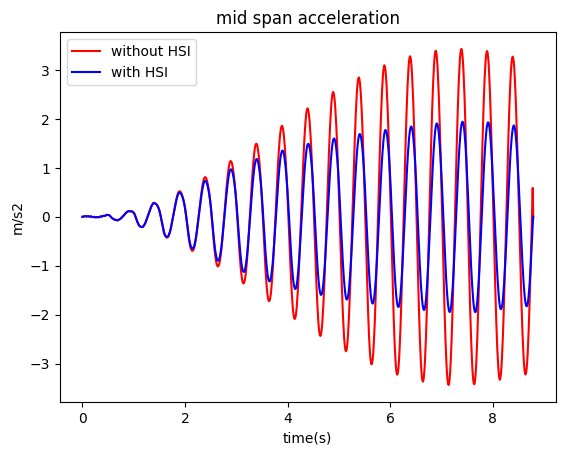

In [1]:
from matrix import*  
from solver import* 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3
#ped
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

#mat=np.zeros(1,numped) #to be extended into probabilistic inputs
mped=np.array([pedmass])
cped = np.array([cped])
kped = np.array([kped])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)

u,du,ddu_hsi = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,kped,cped,xrb,linearMass)
                
accn_hsi = accdyn_super(Bridge,ddu_hsi,x_interested,hht)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


u,du,ddu = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,[0],[0],xrb,linearMass)
                
accn = accdyn_super(Bridge,ddu,x_interested,hht)

t = np.arange(0, (length+1) / pedvelocity, hht)
plt.plot(t,accn , label ="without HSI" ,color='r')
plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)

[[ 0.00000000e+00  9.70975888e-02  1.91030370e-01 ... -5.74545690e+01
  -4.17166466e+01  0.00000000e+00]
 [ 0.00000000e+00  1.83059241e-01  3.18985030e-01 ... -8.03168837e+00
  -9.20974631e+00  0.00000000e+00]
 [ 0.00000000e+00  2.19939345e-01  2.21434331e-01 ... -9.10326506e-02
  -1.43284782e-01  0.00000000e+00]
 [ 0.00000000e+00  5.89985287e-06  4.18152938e-05 ... -1.52754553e-03
  -7.82689714e-04  0.00000000e+00]]
[[  0.           0.09709763   0.19103089 ...   9.37666468  29.25872325
    0.        ]
 [  0.           0.18305931   0.318986   ...  -7.84351879 -10.78054276
    0.        ]
 [  0.           0.21993943   0.22143543 ...  -0.09097453  -0.14200324
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]


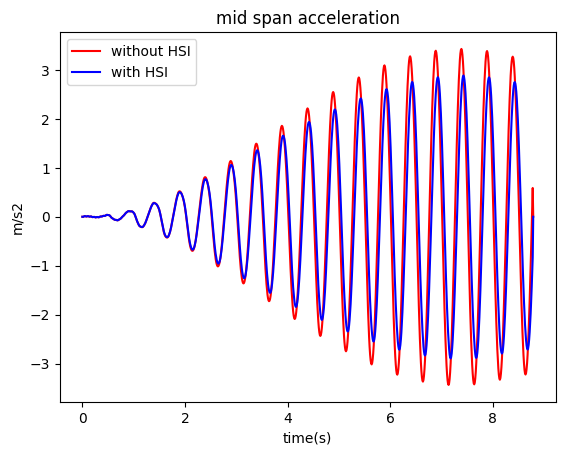

In [2]:
from matrix import*  
from solver import* 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3
#ped
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 3.25 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

#mat=np.zeros(1,numped) #to be extended into probabilistic inputs
mped=np.array([pedmass])
cped = np.array([cped])
kped = np.array([kped])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)

u,du,ddu_hsi = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,kped,cped,xrb,linearMass)
                
accn_hsi1 = accdyn_super(Bridge,ddu_hsi,x_interested,hht)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


u,du,ddu = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,[0],[0],xrb,linearMass)
                
accn1 = accdyn_super(Bridge,ddu,x_interested,hht)

t = np.arange(0, (length+1) / pedvelocity, hht)
plt.plot(t,accn1 , label ="without HSI" ,color='r')
plt.plot(t,accn_hsi1,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)